# K-Means — An Illustrated Tour

> Group $n$ points into $k$ clusters by **alternating** between assigning points to the nearest centroid and recomputing the centroid as the mean of its assigned points. Stop when assignments stop moving.

---

**What we cover:**
- The objective — within-cluster sum of squares (WCSS / inertia)
- Lloyd's algorithm — alternate assign / update
- Voronoi cells = the decision regions of K-means
- Iteration-by-iteration snapshots — watch the centroids settle
- Choosing $k$ — elbow method + silhouette
- Failure modes — non-spherical clusters, anisotropy, varying density

## The picture — centroids minimise within-cluster variance; cells = Voronoi regions

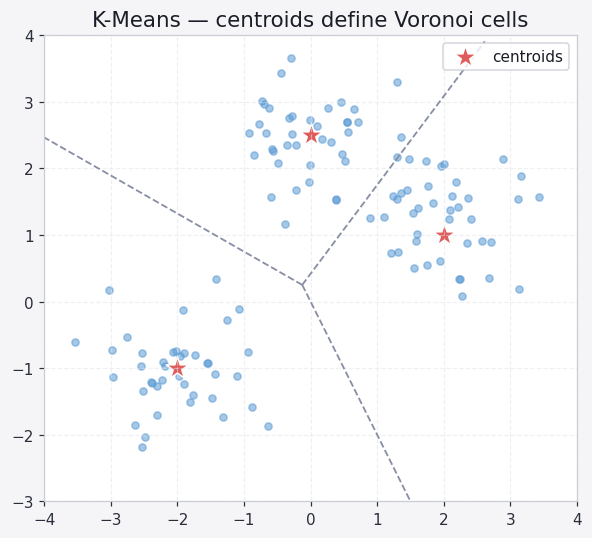

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
centers = np.array([[-2,-1],[2,1],[0,2.5]])
X = np.vstack([c + 0.6*rng.randn(40, 2) for c in centers])
from scipy.spatial import Voronoi, voronoi_plot_2d
vor = Voronoi(centers)
fig, ax = plt.subplots(figsize=(7, 5))
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='#888fa5', line_width=1.2, show_points=False)
ax.scatter(X[:,0], X[:,1], s=22, color=P[0], alpha=0.55)
ax.scatter(centers[:,0], centers[:,1], s=240, marker='*', color=P[1], edgecolor='white', label='centroids')
ax.set_aspect('equal'); ax.set_xlim(-4,4); ax.set_ylim(-3,4)
ax.set_title('K-Means — centroids define Voronoi cells')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import silhouette_score

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'
PALETTE = [C0, C1, CB, CM, CH, CP]

X, y_true = make_blobs(n_samples=200, centers=4, cluster_std=0.8, random_state=7)
print('Data:', X.shape)

Data: (200, 2)


---
## The Objective — Minimise Within-Cluster Spread

K-Means minimises the **within-cluster sum of squares**:

$$J(\mu, c) \;=\; \sum_{i=1}^m \|x^{(i)} - \mu_{c^{(i)}}\|^2$$

where $c^{(i)} \in \{1,\dots,k\}$ is the cluster index of point $x^{(i)}$ and $\mu_j$ is the centroid of cluster $j$.

**Lloyd's algorithm** alternates two steps that each decrease $J$:

1. **Assign**: $c^{(i)} \leftarrow \arg\min_j \|x^{(i)} - \mu_j\|$ (closest centroid).
2. **Update**: $\mu_j \leftarrow \tfrac{1}{n_j}\sum_{i:c^{(i)}=j} x^{(i)}$ (mean of assigned points).

Because $J$ is bounded below by 0 and decreases at each step, Lloyd's algorithm always converges — though only to a **local** minimum that depends on the initialisation.

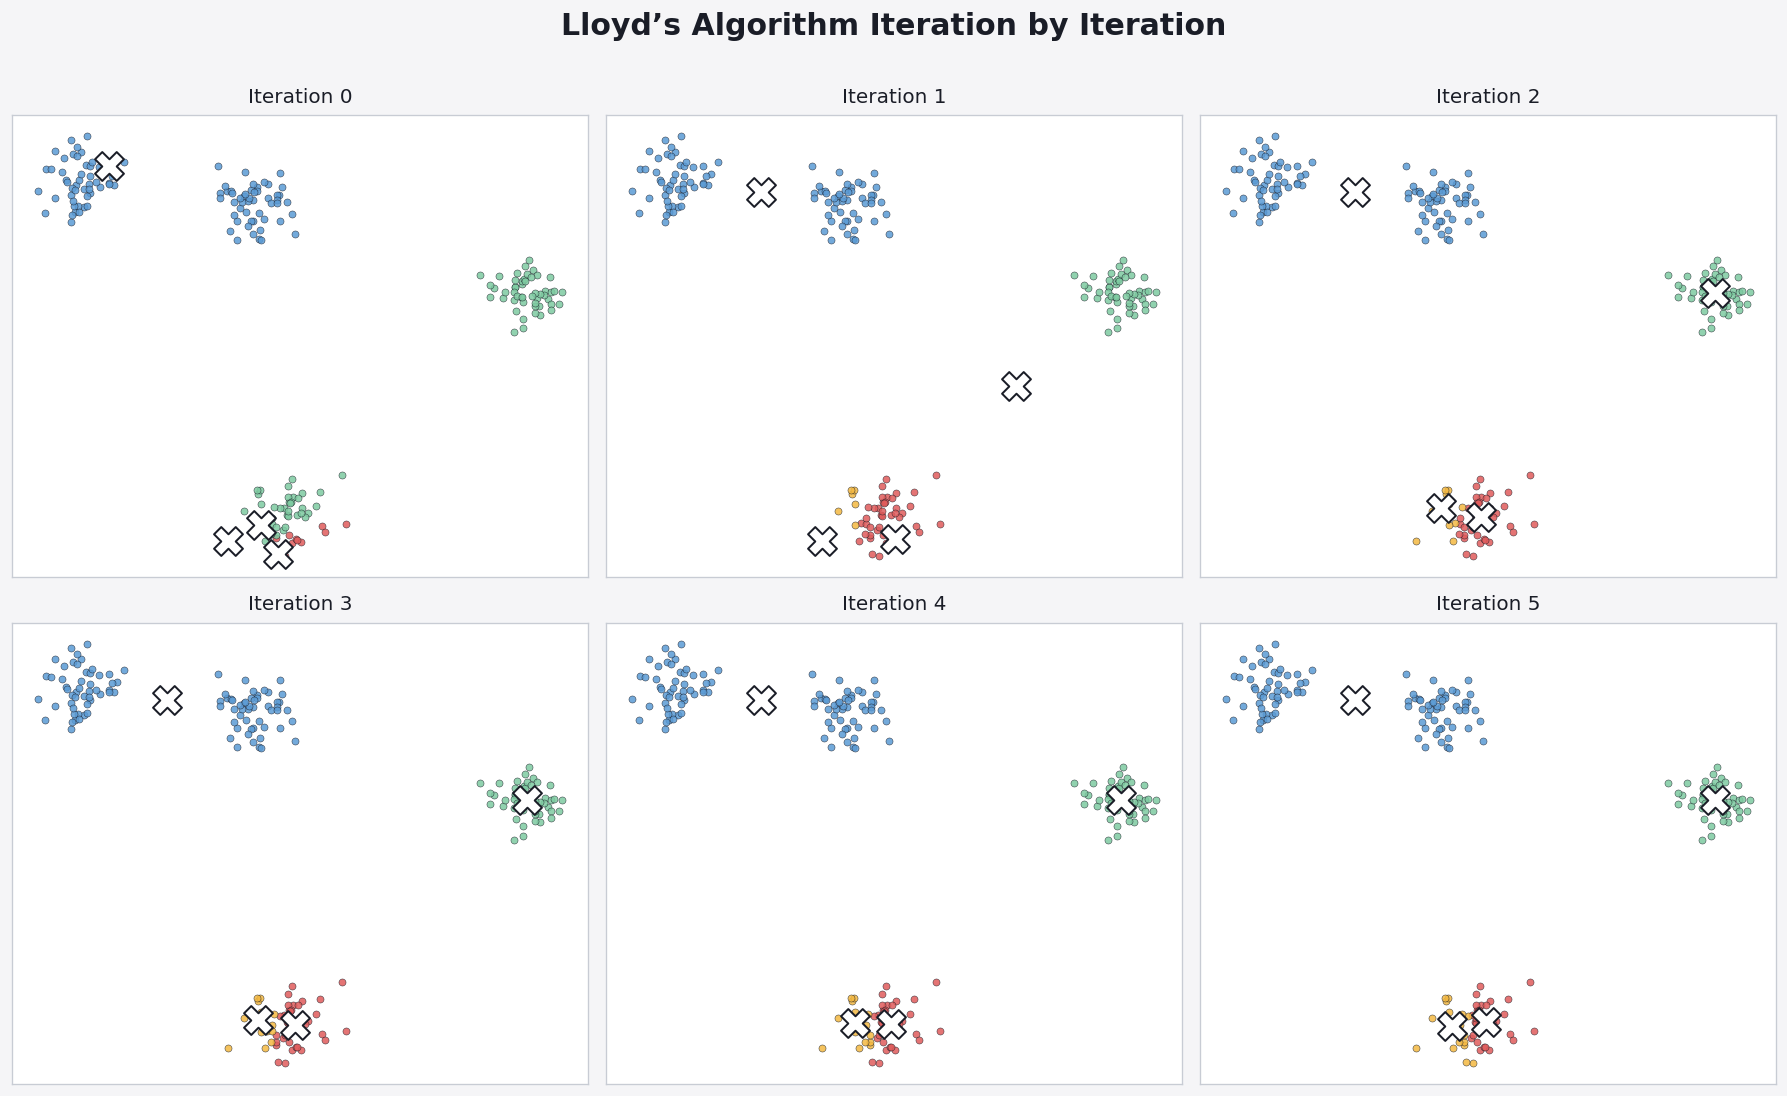

In [3]:
# Manual Lloyd's iterations to capture snapshots
rng = np.random.default_rng(0)
K = 4
centroids = X[rng.choice(len(X), K, replace=False)].copy()
snapshots = [centroids.copy()]
labels = None
for _ in range(8):
    d = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    labels = np.argmin(d, axis=1)
    new_c = np.array([X[labels == j].mean(axis=0) for j in range(K)])
    if np.allclose(new_c, centroids): break
    centroids = new_c
    snapshots.append(centroids.copy())

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (i, c_snap) in zip(axes.flat, enumerate(snapshots[:6])):
    d = np.linalg.norm(X[:, None, :] - c_snap[None, :, :], axis=2)
    lbl = np.argmin(d, axis=1)
    for j in range(K):
        m = lbl == j
        ax.scatter(X[m,0], X[m,1], c=PALETTE[j], s=18, edgecolors='#1a1d27', lw=0.3, alpha=0.85)
    ax.scatter(c_snap[:,0], c_snap[:,1], s=300, c='#ffffff', marker='X',
               edgecolors='#1a1d27', lw=1.2, zorder=5)
    ax.set_title(f'Iteration {i}', fontsize=12, pad=8)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Lloyd\u2019s Algorithm Iteration by Iteration', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Voronoi Cells — The Decision Regions

Once K-means converges, every point in space is assigned to its nearest centroid. The boundaries between assignment regions form a **Voronoi diagram** — a tessellation of the plane into convex polygons. K-means clusters are always convex blobs because of this.

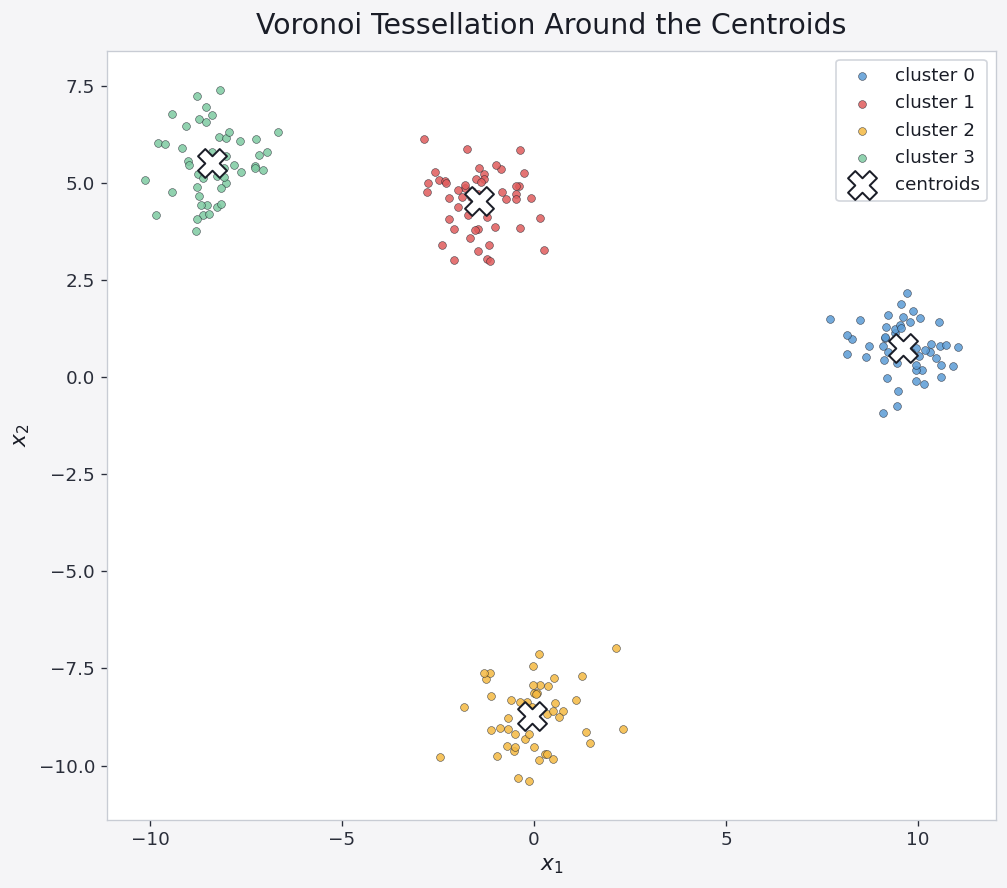

In [4]:
km = KMeans(n_clusters=4, n_init=10, random_state=0).fit(X)
centers = km.cluster_centers_
labels = km.labels_

fig, ax = plt.subplots(figsize=(8.5, 7.5))
vor = Voronoi(centers)
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='#ffffff', line_width=2.0,
                line_alpha=0.85, point_size=0)
for j in range(4):
    m = labels == j
    ax.scatter(X[m,0], X[m,1], c=PALETTE[j], s=22, edgecolors='#1a1d27', lw=0.3, alpha=0.85,
               label=f'cluster {j}')
ax.scatter(centers[:,0], centers[:,1], s=300, c='#ffffff', marker='X', edgecolors='#1a1d27', lw=1.2, zorder=6, label='centroids')
ax.set_xlim(X[:,0].min()-1, X[:,0].max()+1); ax.set_ylim(X[:,1].min()-1, X[:,1].max()+1)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Voronoi Tessellation Around the Centroids', pad=10)
ax.legend(loc='upper right'); ax.grid(False)
plt.tight_layout(); plt.show()

---
## Choosing $k$ — Elbow & Silhouette

$k$ is a hyperparameter. Two diagnostics help.

- **Elbow plot**: inertia $J(k)$ keeps falling as $k$ grows. Look for the **kink** where the marginal benefit drops.
- **Silhouette score** $\in [-1, 1]$: average of $\frac{b - a}{\max(a, b)}$, where $a$ is mean intra-cluster distance and $b$ is mean nearest-cluster distance. Higher is better; **peak silhouette** often picks the right $k$.

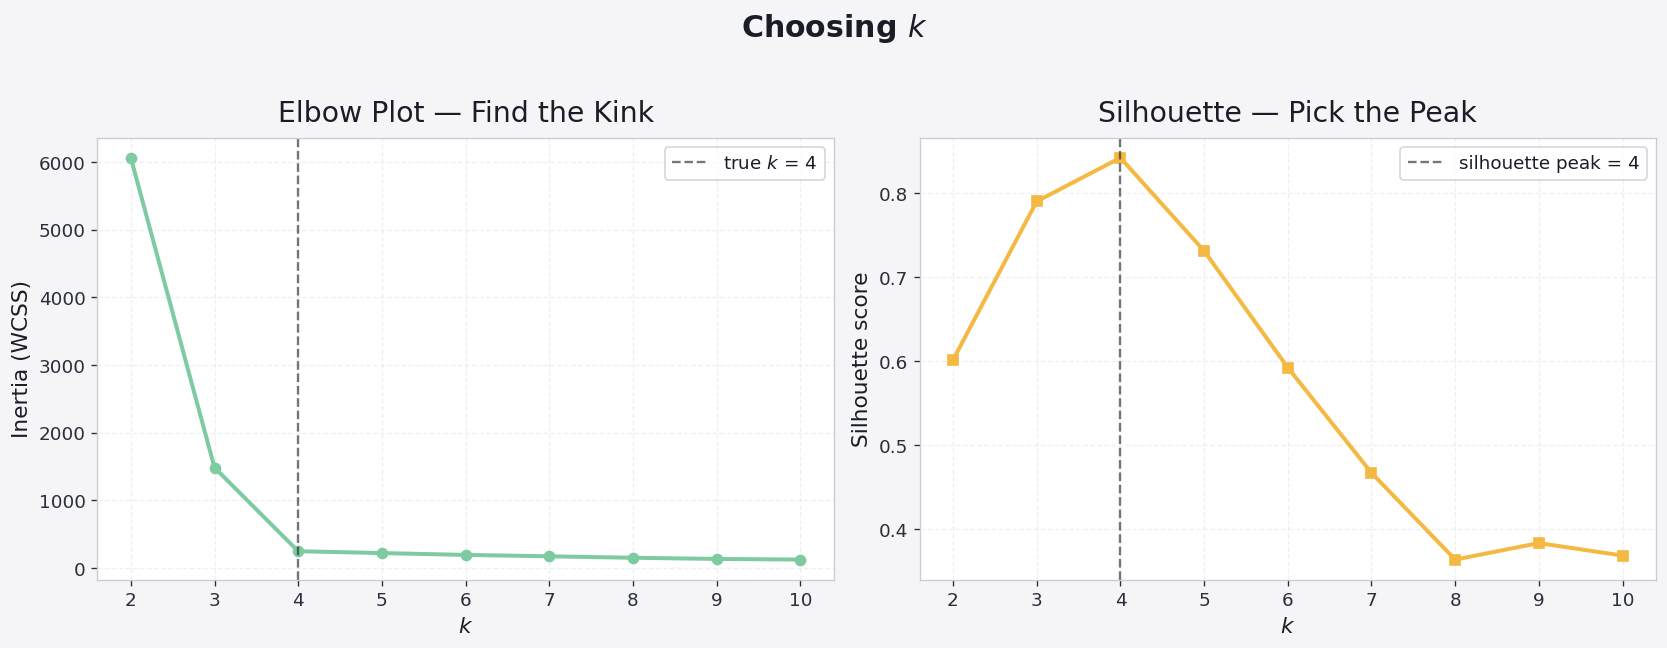

In [5]:
ks = list(range(2, 11))
inertias, sils = [], []
for k in ks:
    m = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    inertias.append(m.inertia_)
    sils.append(silhouette_score(X, m.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
ax = axes[0]
ax.plot(ks, inertias, color=CM, lw=2.4, marker='o', ms=6)
ax.axvline(4, color='#1a1d27', ls='--', lw=1.4, alpha=0.6, label='true $k$ = 4')
ax.set_xlabel('$k$'); ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Elbow Plot — Find the Kink', pad=10); ax.legend(); ax.grid(True)

ax = axes[1]
ax.plot(ks, sils, color=CB, lw=2.4, marker='s', ms=6)
best = ks[int(np.argmax(sils))]
ax.axvline(best, color='#1a1d27', ls='--', lw=1.4, alpha=0.6, label=f'silhouette peak = {best}')
ax.set_xlabel('$k$'); ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette — Pick the Peak', pad=10); ax.legend(); ax.grid(True)

fig.suptitle('Choosing $k$', fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

---
## Failure Modes

K-means assumes clusters are **spherical, similarly sized, and equally dense**. Three pathological cases:

1. **Non-convex shape** (moons): K-means will cut a moon in half because the global mean is not interior.
2. **Anisotropy** (stretched ellipses): a stretched cluster gets split along its long axis.
3. **Wildly different densities**: K-means tries to balance inertia, sometimes stealing points from a dense cluster to feed a sparse one.

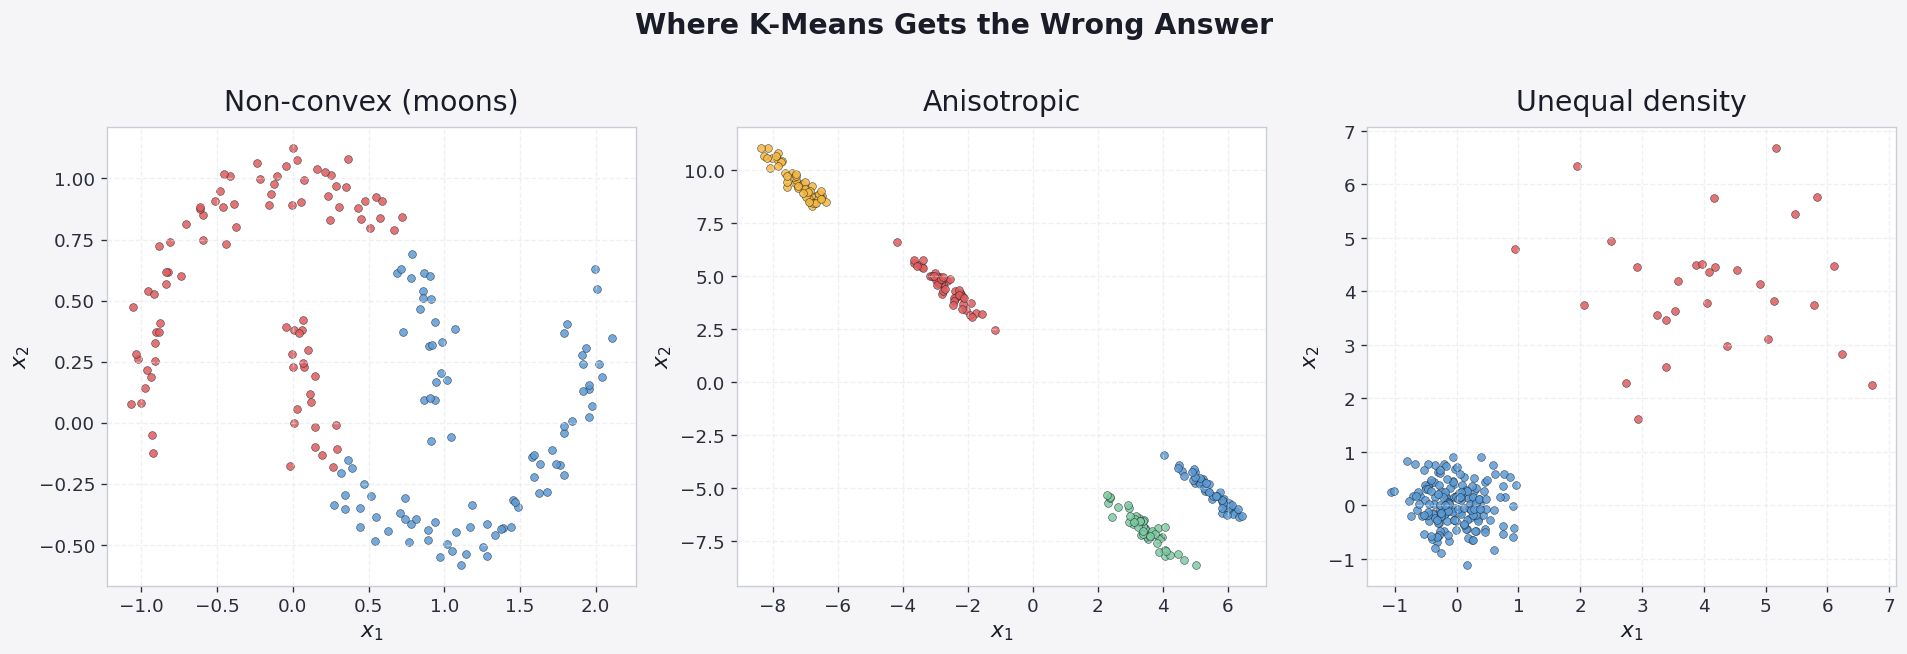

In [6]:
Xm, _ = make_moons(n_samples=180, noise=0.07, random_state=0)
rng = np.random.default_rng(1)
T = np.array([[0.6, -0.6], [-0.4, 0.8]])
X_aniso = X @ T
X_unbal = np.vstack([
    make_blobs(n_samples=180, centers=[(0,0)], cluster_std=0.4, random_state=0)[0],
    make_blobs(n_samples=30, centers=[(4,4)], cluster_std=1.2, random_state=0)[0],
])

datasets = [
    ('Non-convex (moons)', Xm, 2),
    ('Anisotropic',        X_aniso, 4),
    ('Unequal density',    X_unbal, 2),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 5.3))
for ax, (name, Xd, k) in zip(axes, datasets):
    lbl = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xd)
    for j in range(k):
        m = lbl == j
        ax.scatter(Xd[m,0], Xd[m,1], c=PALETTE[j], s=22, edgecolors='#1a1d27', lw=0.3, alpha=0.85)
    ax.set_title(name, pad=10); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)
fig.suptitle('Where K-Means Gets the Wrong Answer', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use K-Means — and when not to

| Situation | K-Means | GMM | DBSCAN | Hierarchical |
|---|---|---|---|---|
| Roughly spherical, equal-size clusters | ✅ | ✅ | partial | partial |
| Variable cluster shapes | ❌ | partial | ✅ | partial |
| Don't know $k$ in advance | ❌ | ❌ | ✅ | ✅ |
| Very large $n$ | ✅ mini-batch | partial | partial | ❌ |

> K-Means is the **first model** to try when you suspect blob-shaped clusters and can guess $k$.


---
## 🎯 Try this

1. **Sensitivity to init.** Run plain K-Means and K-Means++ ten times each. The plain version's inertia variance should be much higher.
2. **Elbow vs silhouette.** Plot inertia and silhouette score for $k=2 \dots 10$. They often disagree — pick the $k$ that matches your downstream task.
3. **K-Means on PCA features.** Run K-Means on raw images vs on the top 50 PCA components. The PCA-based clusters are usually cleaner *and* faster to compute.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Objective $J$ | Sum of squared distances to assigned centroid | Decreases monotonically under Lloyd's |
| Assign step | Each point $\to$ closest centroid | Voronoi partition |
| Update step | Each centroid $\to$ mean of its points | Closed-form minimiser of $J$ given assignments |
| `k-means++` init | Spreads initial centroids by distance | Drastically reduces bad local optima |
| Choosing $k$ | Elbow + silhouette + domain | No single right answer |
| Strength | Fast, simple, scales to millions | Great when clusters are convex blobs |
| Weakness | Spherical assumption, fixed $k$, hard assignments | Use GMM for soft / elliptical, DBSCAN for shapes |

**Bottom line:** K-Means partitions the plane with **straight, convex** Voronoi cells. It's a fantastic baseline whenever cluster geometry is roughly blobby and you have a sense of $k$.